In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("cs1090a_hw1.ipynb")

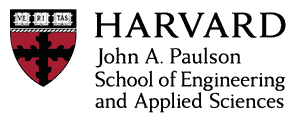

# CS1090A Introduction to Data Science
## Homework 1: A Reproducible Scraping & EDA Pipeline

**Harvard University**<br/>
**Fall 2026**<br/>
**Instructors**: Pavlos Protopapas, Kevin Rader, and Chris Gumb

<hr style="height:2.4pt">

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import os
import json
import time
import glob
import datetime
from concurrent.futures import ThreadPoolExecutor
from IPython import display
import pprint

In [3]:
# For calculating total notebook runtime
notebook_start = time.time()

In [4]:
style = '''<style>
h2, h3, h4 {
    background-color: #7efcf5;
    border-left: 5px solid #7ec4fc;
    border-right: 5px solid #7ec4fc;
    padding: 0em;
    color: #1F2937;
}
h3 {
    background-color: #7efcf5;
    border-top: 5px solid #7ec4fc;
    border-left: 5px solid #7ec4fc;
    border-right: 5px solid #7ec4fc;
    padding: 0.5em;
}
div.md {
    border-left: 5px solid #7ec4fc;
    border-right: 5px solid #7ec4fc;
    border-bottom: 5px solid #7ec4fc;
    padding: 0.5em;
}
div.prompt {
    background: #d1ffbd;
    border: thin solid black;
    border-radius: 2px;
    padding: 5px;
    margin: 0.5em 0;
    color: #1F2937;
}
/* A colour on the box does not reach <code> or <a> inside it. JupyterLab's dark
   theme gives inline code background-color: var(--jp-layout-color2) (#424242) and
   colours links #64b5f6, so setting only the box colour would put dark text on a
   dark code background. Code and links outside a box are left alone, where the
   theme's own pairing is already right. */
div.prompt code, div.alert code {
    background: rgba(0, 0, 0, 0.06);
    color: #1F2937;
}
div.prompt a, div.alert a {
    color: #1D4ED8;
}
</style>'''
display.display(display.HTML(style))

## Assignment Overview

You'll build a **reproducible data pipeline** around
[screenboston.com](https://screenboston.com), a site that aggregates movie
screenings from theaters around Boston. You will collect the data (live page +
historical snapshots), structure it with Pandas, enrich it from Wikipedia, use
EDA and visualization to understand it — and finish by making a **data-driven
recommendation** to the theaters themselves.

Think of the assignment is a structured mini-project. Each question tells
you the **goal**, the **required artifact** (file, variable, or figure), and any
**constraints** — how you get there is up to you. Sections 1–2 and the
supplemental notebooks (*MediaWiki API*, *Matplotlib & Seaborn reference*)
demonstrate every technique you'll need.

**The reproducibility theme.** A grader (or future you) should be able to re-run
your notebook and get the *same dataset and results*. Concretely, throughout
this assignment:

- **Guard every fetch** — code that touches the network must first check for a
  cached copy on disk and skip the request if it exists.
- **Derive results from pinned data** — that is, historical Wayback snapshots and cached
  files, not whatever the live web happens to say today.
- You will **submit your small data files** alongside the notebook (see
  Question 10), so your results are reproducible without the network.

**Structure** (10 questions + wrap-up; CS1090A graded out of 95, AC209A out of
100 — see the AC209A section):

1. Acquire the live page (4 pts)
2. Parse HTML into records (10 pts)
3. A reproducible dataset from Wayback snapshots (12 pts)
4. Build and clean a DataFrame (12 pts)
5. Exploratory data analysis (14 pts)
6. Resolve films to Wikipedia page IDs (8 pts)
7. Cache Wikipedia page content to disk (4 pts)
8. Enrich the data and ask a new question (10 pts)
9. **The decision: program Halloween weekend (14 pts)**
10. Reproducibility reflection & data submission (6 pts)
11. Wrap-up (1 pt)
12. **AC209A only:** SQL + concurrency (5 pts — required for AC209A; CS1090A
    students may skip this section entirely)

## Instructions

<div class="prompt" style="background: lightgreen; border: thin solid black; border-radius: 2px; padding: 5px; color: #1F2937;">

**General**
- To submit your notebook and data files, follow the instructions on the Canvas assignment page.
- **CS1090A is graded out of 95; AC209A is graded out of 100.** Three subquestions are marked *AC209A only*: 6a and 7a (concurrency evidence, 1 point each) and 8a (SQL, 3 points). CS1090A students skip those three and lose nothing by doing so — they are required work for AC209A, not extra credit for anyone.
- Plots must be legible and interpretable *without reading the code that generated them*: axis labels, a descriptive title, and a legend where appropriate.
- When asked to interpret a result, explain what it *means* — not what the plot looks like.
- The automated tests are **smoke tests only**: they check that required artifacts exist and have the right shape. Passing them is necessary, not sufficient — most credit is assigned by rubric to your approach, analysis, and writing.
- Your code must be **re-runnable — including offline**: "Restart Kernel and Run All Cells" must complete without error, and given your submitted data files it must complete *without any network access* (this is how it will be graded). 
- Only make network requests when the corresponding cache is empty. Gratuitous re-fetching (of pages you already saved) will lose credit.
- Feel free to add code or markdown cells. Include a written response wherever a question asks for one.
- **Before submitting: Restart Kernel and Run All Cells**, confirm no errors and that all output is visible.

**Use of AI tools**

AI tools — coding agents especially — are part of the modern data science workflow. One principle governs everything: **you are accountable for whatever you submit.** You must understand it, be able to communicate it, and be able to justify it.

- Written interpretations, the Question 9 memo, and the Question 10 reflection must be **your own reasoning in your own words**.
- In Question 10 you will briefly **disclose** how you used AI on this assignment and what you did to verify its output.
- Remember, any understanding you skip here will be paid for later in quizzes & midterms.
</div>

## Question 1: Acquire the live page

<p>Get the current HTML of <a href="https://screenboston.com">screenboston.com</a> and cache it to disk.</p>

<p><b>Why HTML at all?</b> Before scraping any site, look for structured data first — an official API, or the JSON many modern sites load their pages from. screenboston has one: <code>screenboston.com/__data.json</code> serves the current schedule as JSON, and parsing it would be easier than parsing HTML. We parse HTML anyway for one decisive reason: this assignment's dataset is <i>historical</i>, and the past only exists in the Wayback Machine's snapshots of the <i>rendered page</i>.</p>

<div class=prompt>

**Artifact:** the file <code>data/html/screenboston.html</code>.

**Constraints:**
- The fetch must be <b>guarded</b>: make an HTTP request only if the file does not already exist.
- <b>Identify yourself</b>: send a descriptive <code>User-Agent</code> naming the course. Some sites block anonymous default clients.
</div>

<p><b>Note what you just built:</b> this file is the one piece of your dataset that is <i>not</i> reproducible — it captures whatever the site showed on the day you ran this cell. (We'll fix that in Question 3)</p>

In [5]:
# your code here
os.makedirs("data/html", exist_ok=True)
if not os.path.exists("data/html/screenboston.html"):
    r = requests.get("https://screenboston.com",
                     headers={"User-Agent": "CS1090A HW1 (Harvard) - terrysu@g.harvard.edu"})
    with open("data/html/screenboston.html", "w") as f:
        f.write(r.text)

In [6]:
grader.check("q1")

q1 results: All test cases passed!

## Question 2: Parse the HTML into records

<p>Turn the page into structured data: one record per screening (a film, at a theater, on a date).</p>

<div class=prompt>

**Artifact:** a list of dictionaries named <code>movies</code>, one per screening, each with <i>exactly</i> these keys:

```python
{'title': 'Monty Python and the Holy Grail',
 'directors': 'Terry Jones, Terry Gilliam',   # plural key, even for one director
 'year': 1975,                                 # int
 'genre': 'Adventure',
 'runtime': '1h 31m',
 'theater': 'Coolidge Corner Theatre',
 'screen_date': '2026-07-11',
 'screen_times': '11:59 PM'}
```

**Constraints:**
- Write your parsing as <b>reusable function(s)</b> that take an HTML string — Question 3 will run them on ~20 more pages.
- Report how many records you extracted and display one example.
- Some listings are missing fields; a record with a <code>None</code> value is fine, but don't let one malformed listing crash the whole parse.
- <b>Never fail silently.</b> Your parser must also report how many listings it <i>failed</i> to parse. A page whose structure has drifted enough to break the parser should announce itself ("parsed 0 of 66 listings") — silent errors cause issues downstream and are a nightmare to debug.
</div>

**Hints:** your browser's *inspect* tool is how you learn the page's structure. Screening dates are not inside each listing — look at what *contains* the listings.

In [7]:
# your code here
def text_of(tag):
    if tag is None:
        return None
    return re.sub(r'\s+', ' ', tag.get_text(' ', strip=True)).strip() or None

def split_details(line):
    year = genre = runtime = None
    for part in [p.strip() for p in (line or '').split(',')]:
        if re.fullmatch(r'\d{4}', part):
            year = int(part)
        elif re.fullmatch(r'\d+h( \d+m)?|\d+m', part):
            runtime = part
        elif re.fullmatch(r'DCP|\d{2}mm|Digital|\d+K', part, re.I):
            pass
        elif part and genre is None:
            genre = part
    return year, genre, runtime

def parse_card(card, screen_date):
    title = text_of(card.find('p', class_='big'))
    details = card.find('div', class_='child:flex-1')
    if details is None or title is None:
        return None
    columns = details.find_all('div', recursive=False)
    left = columns[0].find_all('p', recursive=False) if columns else []
    directors = text_of(left[0]) if left else None
    year, genre, runtime = split_details(text_of(left[1])) if len(left) > 1 else (None, None, None)
    theater = screen_times = None
    if len(columns) > 1:
        theater = text_of(columns[1].find('p', recursive=False))
        times = columns[1].find('div')
        if times is not None:
            screen_times = ', '.join(t for t in map(text_of, times.find_all('p')) if t) or None
    if theater is None:
        return None
    return {'title': title, 'directors': directors, 'year': year, 'genre': genre,
            'runtime': runtime, 'theater': theater, 'screen_date': screen_date,
            'screen_times': screen_times}

def days_and_cards(soup):
    days = [(d['id'], d.find_all('button'))
            for d in soup.find_all('div', class_='max-w-screen', id=True)
            if re.fullmatch(r'\d{4}-\d{2}-\d{2}', d['id'])]
    if days:
        return days
    built_for = soup.find('button', string=re.compile(r'\w{3} \w{3} \d{1,2} \d{4}'))
    if built_for is None:
        return []
    today = datetime.datetime.strptime(text_of(built_for), '%a %b %d %Y').date()
    for header in soup.find_all('p', class_=['big', 'col-span-1']):
        label = re.match(r'\w{3} (\w{3} \d{1,2})', text_of(header) or '')
        if label is None:
            continue
        day = datetime.datetime.strptime(f'{label.group(1)} {today.year}', '%b %d %Y').date()
        if (day - today).days < -180:
            day = day.replace(year=day.year + 1)
        days.append((day.isoformat(), header.parent.find_all('a')))
    return days

def parse_screenboston_html(html_str, source=''):
    soup = BeautifulSoup(html_str, 'html.parser')
    movies, failed = [], 0
    for screen_date, cards in days_and_cards(soup):
        for card in cards:
            record = parse_card(card, screen_date)
            if record is not None:
                movies.append(record)
            elif card.find('p', class_='big') is not None:
                failed += 1
    titles_on_page = html_str.count('big whitespace-normal')
    seen = len(movies) + failed
    print(f'{source}: parsed {len(movies)} of {seen} listings ({failed} failed)')
    if seen == 0:
        print('  nothing parsed at all: this page matches neither layout')
    elif titles_on_page > seen:
        print(f'  only reached {seen} of {titles_on_page} listing titles on the page')
    return movies

with open('data/html/screenboston.html', encoding='utf-8') as f:
    movies = parse_screenboston_html(f.read(), 'screenboston.html')

print(f'\n{len(movies)} records. First one:')
pprint.pprint(movies[0])

screenboston.html: parsed 123 of 123 listings (0 failed)

123 records. First one:
{'directors': 'Florian Henckel von Donnersmarck',
 'genre': 'Drama',
 'runtime': '2h 17m',
 'screen_date': '2026-09-17',
 'screen_times': '4:00 PM',
 'theater': 'West Newton Cinema',
 'title': 'The Lives of Others',
 'year': 2006}


In [8]:
grader.check("q2")

q2 results: All test cases passed!

## Question 3: A reproducible dataset from Wayback snapshots

<p>The live page only shows the next couple of weeks. The Internet Archive's
<a href="https://archive.org/help/wayback_api.php">Wayback Machine availability API</a> lets you retrieve historical snapshots of the page — and because snapshots are <b>pinned</b>, a dataset built from them is reproducible.</p>

<div class=prompt>

**Artifacts:**
1. Snapshot HTML files saved as <code>data/html/snapshot_YYYYMMDD.html</code> — covering <b>all available snapshots</b> of screenboston.com <b>through September 8, 2026</b>.
2. <code>data/movies.json</code> — the combined list of screening records parsed from <i>every</i> HTML file in <code>data/html/</code> (snapshots + live page), written with the <code>json</code> module.

**Constraints:**
- Both steps must be <b>guarded</b> (i.e., check for existing cache before running) — and guard <b>per file</b>, so an interrupted run resumes instead of restarting (or worse, permanently locking in a partial download).
- <b>The archive spans a site redesign.</b> These snapshots run over two years, and
screenboston.com did not look the same throughout. At least one early snapshot will not
parse with selectors written for today's page. Your parser must <b>say so</b> rather than
quietly return an empty list — that is what "never fail silently" in Q2 was for.
<i>Extracting that page's listings anyway is optional and worth a bonus point</i>; be
warned that the older layout carries no release year at all, so <code>year</code> would
have to be <code>None</code> for those records.
- <b>Expect throttling and handle it.</b> The whole class hits archive.org the same week; you *will* see slow responses or HTTP 429. Check status codes before parsing or saving anything — a cached error page is worse than no cache (since a simple guard can't tell them apart). Sanity-check each saved snapshot (does it parse to a plausible number of listings?).
- Assume any well-formed page covers at least through the end of its snapshot month, and that a day's schedule doesn't change once displayed.
- Don't worry about duplicate screenings across overlapping snapshots — Question 4 deals with them.
- Report which snapshots you found and the total number of records.
</div>

**Hint:** the availability API returns the snapshot *closest* to a timestamp — probing one timestamp per month is a reasonable way to sweep the archive's history. Store your list in `movies` (it should now include records from all pages).

In [9]:
# your code here
headers = {'User-Agent': 'CS1090A HW1 (Harvard) - terrysu@g.harvard.edu'}
index_path = 'data/wayback_index.json'
os.makedirs('data/html', exist_ok=True)

if os.path.exists(index_path):
    with open(index_path) as f:
        snapshots = json.load(f)
else:
    r = requests.get('https://web.archive.org/cdx/search/cdx', headers=headers, timeout=60,
                     params={'url': 'screenboston.com/', 'output': 'json',
                             'fl': 'timestamp,original', 'collapse': 'timestamp:8',
                             'filter': ['statuscode:200', 'mimetype:text/html'],
                             'from': '20240101', 'to': '20260908235959'})
    r.raise_for_status()
    snapshots = [{'timestamp': ts, 'url': url} for ts, url in r.json()[1:]]
    with open(index_path, 'w') as f:
        json.dump(snapshots, f, indent=2)

snapshots = sorted((s for s in snapshots if '20240101' <= s['timestamp'][:8] <= '20260908'),
                   key=lambda s: s['timestamp'])
print(f'{len(snapshots)} captures listed through 2026-09-08')

for snap in snapshots:
    if snap.get('saved_as') and os.path.exists(f"data/html/{snap['saved_as']}"):
        continue

    r = None
    for attempt in range(4):
        try:
            r = requests.get(f"https://web.archive.org/web/{snap['timestamp']}id_/{snap['url']}",
                             headers=headers, timeout=60)
            r.raise_for_status()
            r.encoding = 'utf-8'
            break
        except requests.RequestException as err:
            print(f"  {snap['timestamp'][:8]}: {err}")
            r = None
            if attempt < 3:
                time.sleep(20 * (attempt + 1))
    if r is None:
        continue

    served = re.search(r'/web/(\d{14})', r.url)
    served = served.group(1) if served else snap['timestamp']
    if served != snap['timestamp']:
        print(f"  {snap['timestamp'][:8]} is not replayable; archive served {served[:8]}")

    path = f'data/html/snapshot_{served[:8]}.html'
    if not os.path.exists(path):
        if not parse_screenboston_html(r.text, f'snapshot_{served[:8]}'):
            print(f'  {served[:8]}: parsed nothing, not caching it')
            continue
        with open(path, 'w', encoding='utf-8') as f:
            f.write(r.text)
        time.sleep(2)
    snap['saved_as'] = os.path.basename(path)

with open(index_path, 'w') as f:
    json.dump(snapshots, f, indent=2)

missing = [s['timestamp'][:8] for s in snapshots if not s.get('saved_as')]
if missing:
    print('Could not retrieve:', ', '.join(missing))

62 captures listed through 2026-09-08


In [10]:
# your code here
movies_path = 'data/movies.json'
html_files = sorted(glob.glob('data/html/*.html'))

if (os.path.exists(movies_path) and
        os.path.getmtime(movies_path) > max(os.path.getmtime(f) for f in html_files)):
    with open(movies_path) as f:
        movies = json.load(f)
    print(f'Loaded {len(movies)} records from {movies_path}')
else:
    movies, per_file = [], []
    for path in html_files:
        with open(path, encoding='utf-8') as f:
            records = parse_screenboston_html(f.read(), os.path.basename(path))
        movies += records
        per_file.append({'file': os.path.basename(path), 'records': len(records)})
    with open(movies_path, 'w', encoding='utf-8') as f:
        json.dump(movies, f, indent=2, ensure_ascii=False)
    print(f'\nWrote {len(movies)} records to {movies_path}')
    display.display(pd.DataFrame(per_file))

Loaded 5636 records from data/movies.json


In [11]:
# Display info about snapshots and parse results
print("Snapshots on disk:")
print(sorted(os.path.basename(f) for f in glob.glob('data/html/snapshot_*')))
print(f"{len(movies)} total screening records across all HTML files.")

Snapshots on disk:
['snapshot_20240328.html', 'snapshot_20240524.html', 'snapshot_20240621.html', 'snapshot_20240727.html', 'snapshot_20240803.html', 'snapshot_20240812.html', 'snapshot_20240904.html', 'snapshot_20240912.html', 'snapshot_20240921.html', 'snapshot_20240924.html', 'snapshot_20240926.html', 'snapshot_20241006.html', 'snapshot_20241101.html', 'snapshot_20241108.html', 'snapshot_20241119.html', 'snapshot_20241206.html', 'snapshot_20241210.html', 'snapshot_20241211.html', 'snapshot_20241212.html', 'snapshot_20241214.html', 'snapshot_20241216.html', 'snapshot_20241219.html', 'snapshot_20241226.html', 'snapshot_20250105.html', 'snapshot_20250109.html', 'snapshot_20250116.html', 'snapshot_20250126.html', 'snapshot_20250129.html', 'snapshot_20250131.html', 'snapshot_20250210.html', 'snapshot_20250217.html', 'snapshot_20250326.html', 'snapshot_20250416.html', 'snapshot_20250425.html', 'snapshot_20250428.html', 'snapshot_20250515.html', 'snapshot_20250616.html', 'snapshot_20250622

In [12]:
grader.check("q3")

q3 results: All test cases passed!

## Question 4: Build and clean a DataFrame

<div class=prompt>

**Artifact:** a DataFrame <code>df</code> built from <code>data/movies.json</code>, satisfying:

1. **No duplicate rows** (rows where *all* values match — overlapping snapshots create many). Report how many rows you dropped and how many remain.
2. A **missingness audit**: NaN counts per column, and a display of the rows containing at least one NaN (or confirmation there are none).
3. **A dtype on each column that matches what the column holds**: <code>screen_date</code> as a datetime type, <code>runtime</code> as a timedelta type.
4. Sorted by ascending <code>screen_date</code>.

<b>Verify as you go</b> — after each transform, check what you actually produced (<code>.shape</code>, <code>.dtypes</code>, a spot-check of rows). Whether you or an 'assistant' wrote the code, the sign-off on the result is your responsibility.

Then use the clean frame to create:

5. A table of **screenings per theater per calendar month** (rows = month, columns = theater; restrict columns to the 6 busiest theaters). Then, in one or two sentences: what do you notice?
</div>

In [13]:
# your code here
with open('data/movies.json') as f:
    df = pd.DataFrame(json.load(f))
print('records as parsed:', df.shape)

before = len(df)
df = df.drop_duplicates(ignore_index=True)
print(f'dropped {before - len(df)} duplicate rows, {len(df)} unique screenings left')

df['screen_date'] = pd.to_datetime(df['screen_date'])
df['runtime'] = pd.to_timedelta(df['runtime'].str.replace('h', ' hours').str.replace('m', ' minutes'))
df['year'] = df['year'].astype('Int64')
df['theater'] = df['theater'].astype('category')
df['genre'] = df['genre'].astype('category')
print(df.dtypes)

records as parsed: (5636, 8)
dropped 2843 duplicate rows, 2793 unique screenings left
title                       str
directors                   str
year                      Int64
genre                  category
runtime         timedelta64[us]
theater                category
screen_date      datetime64[us]
screen_times                str
dtype: object


In [14]:
print('screen_date:', df['screen_date'].min().date(), 'to', df['screen_date'].max().date())
print('runtime:    ', df['runtime'].min(), 'to', df['runtime'].max())
print('year:       ', df['year'].min(), 'to', df['year'].max())

impossible = (df['year'] > 2026) | (df['runtime'] == pd.Timedelta(0))
display.display(df.loc[impossible, ['title', 'year', 'runtime', 'theater', 'screen_date']])

df.loc[df['year'] > 2026, 'year'] = pd.NA
df.loc[df['runtime'] == pd.Timedelta(0), 'runtime'] = pd.NaT

print(f"\nNaN per column ({df.isna().any(axis=1).sum()} rows carry at least one):")
print(df.isna().sum())
display.display(df[df.isna().any(axis=1)])

screen_date: 2024-03-30 to 2026-10-15
runtime:     0 days 00:00:00 to 1 days 00:00:00
year:        1896 to 6666


,title,year,runtime,theater,screen_date
543,RPM Fest Presents: Karel Doing,1998,0 days 00:00:00,The Brattle,2024-09-29
626,"Rebel: Loreta Velazquez, Secret Soldier of the...",2013,0 days 00:00:00,West Newton Cinema,2024-09-27
1684,Sticker Movie,2023,0 days 00:00:00,Goethe-Institut,2025-09-13
1719,Eno,2024,0 days 00:00:00,The Brattle,2025-09-17
2697,Wicked VHS presents: A Secret Summer Camp Slasher,6666,0 days 01:30:00,Coolidge Corner Theatre,2026-08-14
2711,Wicked VHS presents: A Secret Summer Camp Slas...,6666,0 days 01:50:00,Coolidge Corner Theatre,2026-08-28
2769,Mass Mini Con presents: A Mutant Mystery Movie 3,6666,0 days 02:00:00,Coolidge Corner Theatre,2026-09-12



NaN per column (18 rows carry at least one):
title            0
directors        0
year             5
genre           10
runtime          4
theater          0
screen_date      0
screen_times     0
dtype: int64


,title,directors,year,genre,runtime,theater,screen_date,screen_times
123,Blue Giant,Yuzuru Tachikawa,<NA>,Thriller,0 days 02:00:00,Museum of Fine Arts,2024-03-30,7:00 PM
124,Perfect Days,Wim Wenders,<NA>,Thriller,0 days 02:03:00,Museum of Fine Arts,2024-04-05,7:00 PM
543,RPM Fest Presents: Karel Doing,Karel Doing,1998,Documentary,NaT,The Brattle,2024-09-29,1:00 PM
624,I'm Not The River Jhelum,Prabhash Chandra,2021,NaN,0 days 01:36:00,MassArt,2024-09-25,5:00 PM
626,"Rebel: Loreta Velazquez, Secret Soldier of the...",Maria Agui Carter,2013,NaN,NaT,West Newton Cinema,2024-09-27,6:00 PM
627,Out of Sight,Nick Rowland,2015,NaN,0 days 00:28:00,West Newton Cinema,2024-09-27,7:45 PM
1036,You Look Like a Carriage That Not Even the Oxe...,Nelson Carlos de los Santos Arias,2013,NaN,0 days 01:24:00,Harvard Film Archive,2025-02-07,9:45 PM
1237,Alpe-Adria Underground!,"Matevž Jerman, Jurij Meden",2024,NaN,0 days 01:38:00,Harvard Film Archive,2025-04-13,7:00 PM
1379,Shadow of the House,Allie Humenuk,2007,NaN,0 days 01:14:00,West Newton Cinema,2025-05-15,5:30 PM
1676,I like America and America likes Me,Helmut Wietz,1974,NaN,0 days 00:40:00,Goethe-Institut,2025-09-12,6:00 PM


In [15]:
df = df.sort_values('screen_date', ignore_index=True)
print(df.shape, '| sorted:', df['screen_date'].is_monotonic_increasing,
      '| duplicates:', df.duplicated().sum())
display.display(df.head(3))

(2793, 8) | sorted: True | duplicates: 0


,title,directors,year,genre,runtime,theater,screen_date,screen_times
0,Blue Giant,Yuzuru Tachikawa,<NA>,Thriller,0 days 02:00:00,Museum of Fine Arts,2024-03-30,7:00 PM
1,Perfect Days,Wim Wenders,<NA>,Thriller,0 days 02:03:00,Museum of Fine Arts,2024-04-05,7:00 PM
2,Stray Dog,Akira Kurosawa,1949,Crime,0 days 02:02:00,The Brattle,2024-05-24,6:30 PM


In [16]:
# your code here
busiest = df['theater'].value_counts().head(6).index
monthly = (df.assign(month=df['screen_date'].dt.to_period('M'))
             .pivot_table(index='month', columns='theater', values='title',
                          aggfunc='count', observed=True)
             .reindex(columns=busiest))

days_seen = (df.assign(month=df['screen_date'].dt.to_period('M'))
               .groupby('month')['screen_date'].nunique())
monthly.insert(0, 'days covered',
               [f'{days_seen[m]}/{m.days_in_month}' for m in monthly.index])

display.display(monthly)
print(f"The Brattle and the Coolidge alone account for "
      f"{df['theater'].value_counts().head(2).sum()} of {len(df)} screenings.")

theater,days covered,The Brattle,Coolidge Corner Theatre,Harvard Film Archive,Somerville Theatre,West Newton Cinema,Museum of Fine Arts
month,,,,,,,
2024-03,1/31,NaN,NaN,NaN,NaN,NaN,1.0
2024-04,1/30,NaN,NaN,NaN,NaN,NaN,1.0
2024-05,8/31,18.0,8.0,NaN,3.0,NaN,3.0
2024-06,30/30,50.0,24.0,NaN,10.0,1.0,9.0
2024-07,25/31,11.0,24.0,NaN,4.0,NaN,NaN
2024-08,31/31,53.0,27.0,NaN,30.0,3.0,1.0
2024-09,28/30,43.0,37.0,26.0,14.0,8.0,1.0
2024-10,31/31,58.0,41.0,26.0,30.0,NaN,3.0
2024-11,29/30,37.0,33.0,22.0,6.0,2.0,2.0


The Brattle and the Coolidge alone account for 1833 of 2793 screenings.


The films in ScreenBoston are mostly dominated by two theaters: The Brattle and Coolidge Corner Theatre based on the data over time. Harvard Film Archive's earliest listing is 2024-09, and some summer months are sparse or missing — though 2025-07 has 12 screenings and 2025-08 has 20. That pattern could be seasonal fluctuation or a sampling gap; missing records do not show that HFA closes for the summer.

In [17]:
grader.check("q4")

q4 results: All test cases passed!

## Question 5: Exploratory data analysis

Every visualization needs: labeled axes, descriptive title, and a written interpretation of what it *means*.
These are relatively simple visualizations. You should really try writing them yourself.

(Note: "Screening" refers to one row of the `df`.)

### 5.1 Longest films

Display the 10 longest reported runtimes (rows, descending).

Then, in one or two sentences: what are these longest entries, and what does that tell you about what the `runtime` column is measuring?

In [18]:
# your code here
longest = df.nlargest(10, 'runtime')[['title', 'year', 'genre', 'runtime', 'theater', 'screen_date']]
display.display(longest)

,title,year,genre,runtime,theater,screen_date
969,Boston Sci-Fi Film Festival Marathon,2025,SciFi,1 days 00:00:00,Somerville Theatre,2025-02-16
2118,51st Annual Boston Science Fiction Film Marathon,2026,SciFi,1 days 00:00:00,Somerville Theatre,2026-02-15
2647,Marathon '77,1977,Drama,0 days 13:00:00,Harvard Film Archive,2026-09-12
1141,The Lord of the Rings Trilogy,2001,Fantasy,0 days 12:45:00,Coolidge Corner Theatre,2025-04-20
1189,The Lord of the Rings Trilogy,2001,Fantasy,0 days 12:45:00,Coolidge Corner Theatre,2025-05-04
2218,The Lord of the Rings Trilogy,2001,Family,0 days 12:45:00,Coolidge Corner Theatre,2026-03-22
2242,The Lord of the Rings Trilogy,2001,Fantasy,0 days 12:45:00,Coolidge Corner Theatre,2026-03-29
573,23rd Halloween Horror Marathon,2024,Horror,0 days 12:00:00,Coolidge Corner Theatre,2024-10-26
1793,24th Halloween Horror Marathon,2025,Horror,0 days 12:00:00,Coolidge Corner Theatre,2025-10-25
1850,GODZILLATHON,1954,Horror,0 days 11:40:00,Somerville Theatre,2025-11-08


The runtime doesn't mean the length of that specific movie. The longest entries means that film festival marathon last the longest time among all the data points. So runtime is the length of the event as programmed, not the length of a film.

### 5.2 Screening counts

Side-by-side subplots with a shared y-axis: screenings by theater, and screenings by genre.

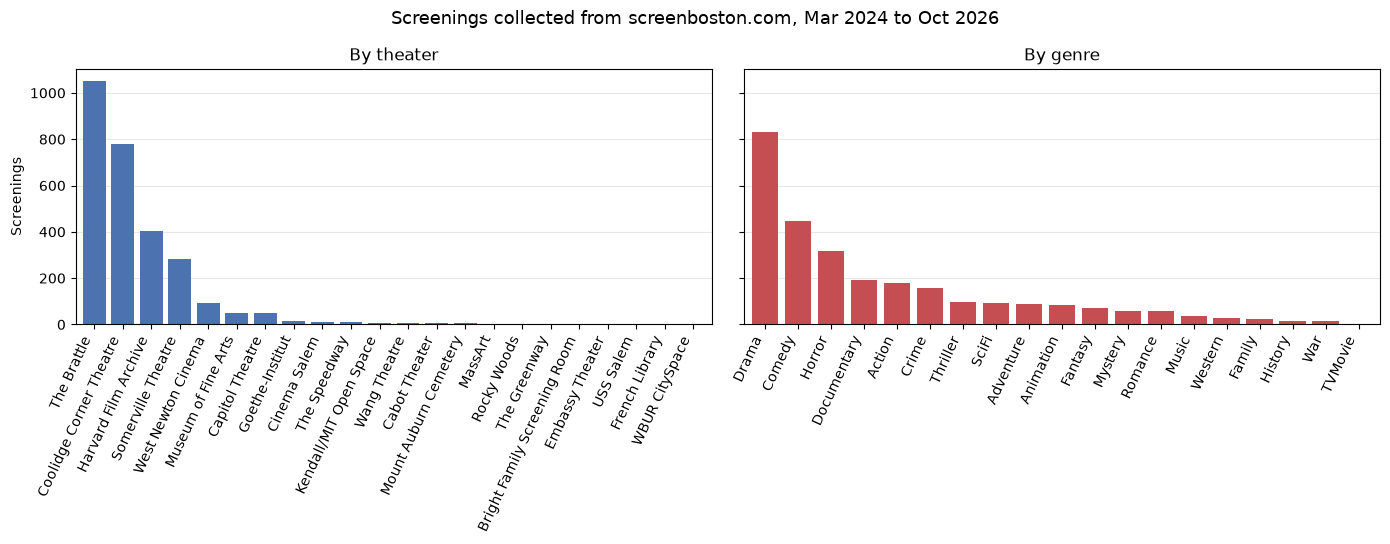

In [19]:
# your code here
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

df['theater'].value_counts().plot.bar(ax=axes[0], color='#4c72b0', width=0.8)
axes[0].set_title('By theater')
axes[0].set_ylabel('Screenings')

df['genre'].value_counts().plot.bar(ax=axes[1], color='#c44e52', width=0.8)
axes[1].set_title('By genre')

for ax in axes:
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelrotation=65)
    plt.setp(ax.get_xticklabels(), ha='right')
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)

fig.suptitle('Screenings collected from screenboston.com, Mar 2024 to Oct 2026',
             fontsize=13)
fig.tight_layout()
plt.show()

Based on left side of the plot we can see the films are dominated by The Brattle and Coolidge Corner Theater. Two plots are both right skewed. 
The plot on the right side shows the films are mostly drama genre.

### 5.3 Film vintage

A pair of plots showing the distribution of release `year`, overall and broken out by theater (your choice of plot types, but justify the choice).

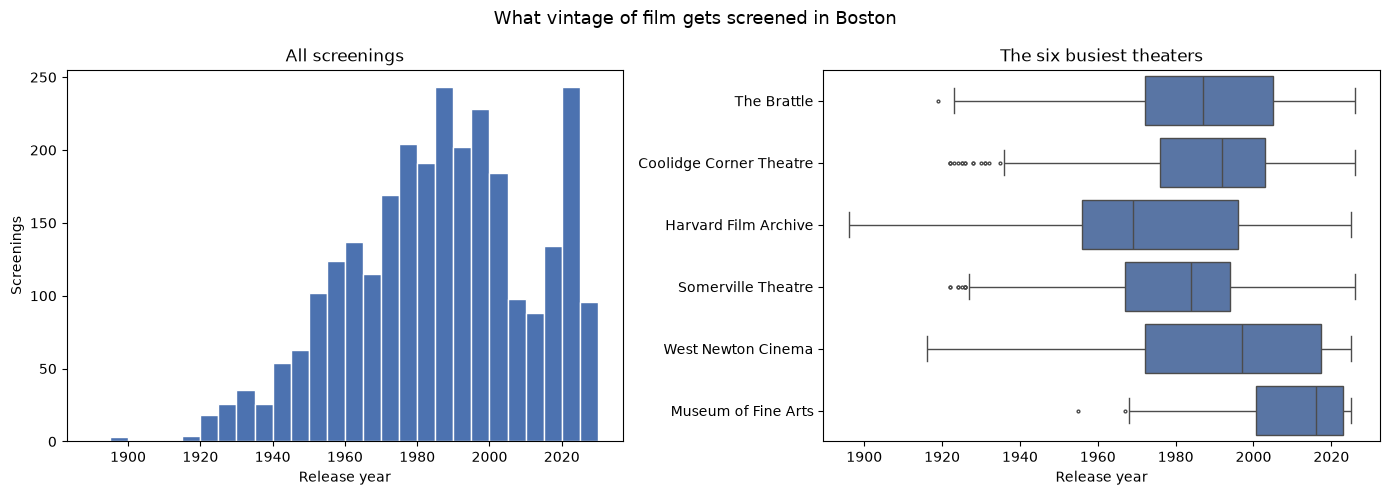

In [20]:
# your code here
busiest = df['theater'].value_counts().head(6).index
by_theater = df[df['theater'].isin(busiest)].dropna(subset=['year'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['year'].dropna(), bins=range(1890, 2035, 5),
             color='#4c72b0', edgecolor='white')
axes[0].set(xlabel='Release year', ylabel='Screenings',
            title='All screenings')

sns.boxplot(data=by_theater, x='year', y='theater', order=busiest,
            ax=axes[1], color='#4c72b0', fliersize=2)
axes[1].set(xlabel='Release year', ylabel='',
            title='The six busiest theaters')
fig.suptitle('What vintage of film gets screened in Boston', fontsize=13)
fig.tight_layout()
plt.show()

The histogram shows a two peak pattern, one peak is between 1980 to 1990 and another peak is around 2020. That demonstrate these theaters do mostly older films, plus a slice of recent work in current release. I choose boxplot on the right side to demonstrate the median and range for different theaters. As we can see from the plot, Museum of fine arts choose mostly new released movies rather than old movies. 

### 5.4 One custom question

Pose a question of your own about the screening data and answer it with an appropriate plot whose *type differs* from those you used above. State the question, your approach, the plot, and your interpretation.

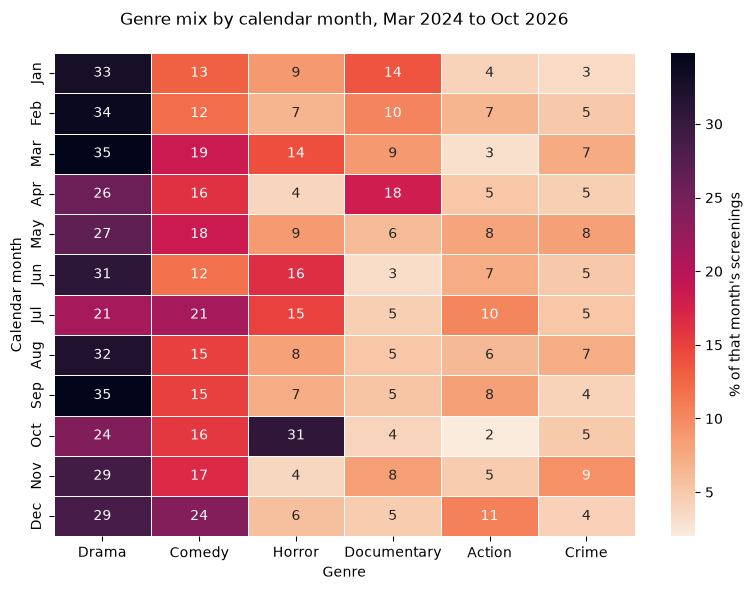

In [21]:
# your code here
top_genres = df['genre'].value_counts().head(6).index
share = pd.crosstab(df['screen_date'].dt.month, df['genre'],
                    normalize='index')[top_genres] * 100
share.index = pd.to_datetime(share.index, format='%m').strftime('%b')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(share, annot=True, fmt='.0f', cmap='rocket_r', ax=ax,
            cbar_kws={'label': '% of that month\'s screenings'}, linewidths=0.5)
ax.set(xlabel='Genre', ylabel='Calendar month',
       title='Genre mix by calendar month, Mar 2024 to Oct 2026\n')
fig.tight_layout()
plt.show()

oct_share = share.loc['Oct', 'Horror']

**Question.** Does the repertory calendar follow the season. I wanted to know whether the October horror tradition is real or not

**Approach.** I pooled three years of data by calendar month and visualized each top genre's monthly share via a heatmap. So that this plot can show a clear comparison between different genre and month.


**Interpretation.** The Halloween effect is real: horror is 31% of October screenings and it collapses to 4% by November.  Drama stays the top of screenings all year, so the seasonal signal is one genre programmed into one specific month by festival, not the whole calendar shifting.

### 5.5 Critique a chart

The provided cell below draws a chart from *your* data, exactly as an over-eager assistant might. It runs without error and looks polished. In a short written answer: what claim does it make, in what specific ways is it misleading, and how would you redraw it so that the visual comparison matches the numbers? (This is the skill the whole module turns on: the tools can draw anything; *you* sign off on what a chart says.)

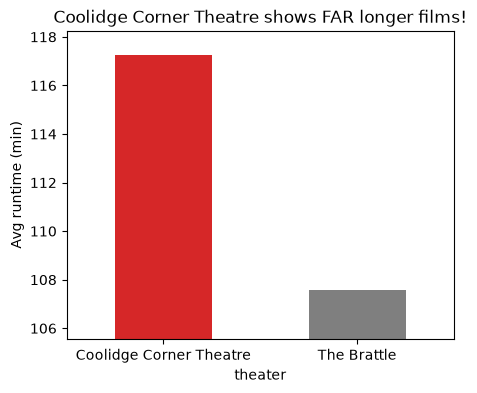

Means: {'Coolidge Corner Theatre': 117.2, 'The Brattle': 107.6}


In [22]:
# --- 5. PROVIDED CELL: do not edit. Critique the chart this draws. ----------
_rt = df.dropna(subset=["runtime"]).copy()
_rt["runtime_min"] = _rt["runtime"].dt.total_seconds() / 60
_top2 = _rt["theater"].value_counts().head(2).index
_means = _rt[_rt["theater"].isin(_top2)].groupby("theater")["runtime_min"].mean()

fig, ax = plt.subplots(figsize=(5, 4))
_means.plot(kind="bar", ax=ax, color=["C3", "C7"], rot=0)
ax.set_ylim(_means.min() - 2, _means.max() + 1)   # <- look closely
ax.set_ylabel("Avg runtime (min)")
ax.set_title(f"{_means.idxmax()} shows FAR longer films!")
plt.show()
print("Means:", _means.round(1).to_dict())

**The claim.** The title show that the Coolidge "shows FAR longer films" than the Brattle, and the bars appear that one bar is roughly three times the height of the other.

**Why it misleads.**

The y-axis is from 105 to 118, so the entire panel shows a 9.6-minute difference (117.2 vs 107.6). Bar charts encode the baseline and turns a 9% difference into a 3x visual. It also use means instead of median, the mean value can be easily influence by some outlier values.

**How I would redraw it.** Start the y-axis at zero. Plot the median rather than the mean. Show all six busiest theaters instead of two, and show the distribution so the reader sees the overlap and the outliers rather than two naked point estimates. 

## Question 6: Resolve films to Wikipedia page IDs

<p>To enrich our data we need a <b>stable identifier</b> for each film's Wikipedia article. Query the <a href="https://www.mediawiki.org/wiki/API:Main_page">MediaWiki API</a> directly with <code>requests</code> — the numeric <code>pageid</code> is permanent even when article titles change. The <i>MediaWiki API</i> supplemental notebook walks through everything you need.</p>

<div class=prompt>

**Artifact:** a <code>wiki_id</code> column on <code>df</code> (the film's numeric pageid, or <code>NaN</code> when you can't resolve one confidently).

**Constraints:**
- Query each <b>unique film</b> once — not once per screening row.
- Cache your resolved IDs to disk (e.g. a CSV) so re-runs make <b>zero</b> lookup requests.
- Be polite: identify yourself with a User-Agent and handle rate-limiting (HTTP 429 / <code>maxlag</code>) gracefully. Sustained one-search-per-film traffic <i>will</i> get you throttled — plan your request budget.
- Report your coverage (share of screenings with a resolved ID) and show a few films you failed to match — what, if anything, do the misses have in common?

**AC209A (required; CS1090A optional):** parallelize whatever per-film requests remain with a small thread pool (max ~4 workers).
</div>

**Hint (request budget):** film articles follow strong title conventions — <i>"Title (YEAR film)"</i>, <i>"Title (film)"</i>, or just <i>"Title"</i>. The API's <code>action=query&titles=a|b|c</code> form checks up to <b>50 exact titles per request</b> (add <code>redirects=1</code>), which resolves most films in a handful of requests; full-text <code>search</code> is then only needed as a fallback for the stragglers. See the MediaWiki supplemental notebook.

In [23]:
# your code here
session = requests.Session()
session.headers.update(headers)
calls = []

def api(**params):
    params.update(format='json', formatversion=2, maxlag=5)
    for attempt in range(5):
        r = session.get('https://en.wikipedia.org/w/api.php', params=params, timeout=60)
        calls.append(r.elapsed.total_seconds())
        if r.ok and (out := r.json()).get('error', {}).get('code') != 'maxlag':
            return out
        if r.status_code not in (200, 429, 503):
            r.raise_for_status()
        time.sleep(float(r.headers.get('Retry-After', 2 ** attempt)))
    raise RuntimeError('MediaWiki kept throttling us')

def lookup(titles):
    params = dict(action='query', titles='|'.join(titles), redirects=1,
                  prop='categories', cllimit='max', clshow='!hidden')
    hop, pages = {}, {}
    while True:
        out = api(**params)
        hop |= {m['from']: m['to'] for k in ('normalized', 'redirects') for m in out['query'].get(k, [])}
        for p in out['query']['pages']:
            if 'missing' not in p:
                pages.setdefault(p['title'], (p['pageid'], set()))[1].update(
                    int(m[1]) for c in p.get('categories', []) if (m := re.fullmatch(r'Category:(\d{4}) films', c['title'])))
        if 'continue' not in out:
            break
        params |= out['continue']
    end = {t: hop.get(hop[t], hop[t]) for t in hop}
    return {t: pages[end.get(t, t)] for t in titles if end.get(t, t) in pages}

def batched(titles):
    titles = list(titles)
    with ThreadPoolExecutor(4) as pool:
        parts = pool.map(lookup, [titles[i:i + 50] for i in range(0, len(titles), 50)])
    return {t: hit for part in parts for t, hit in part.items()}

def is_film(hit, year):
    return bool(hit[1]) and (pd.isna(year) or any(abs(y - int(year)) <= 2 for y in hit[1]))

def search(title, year):
    bare = lambda s: re.findall(r'\w+', re.sub(r'\s*\([^)]*\)$', '', s).casefold())
    query = f'{title} film' if pd.isna(year) else f'{title} {year} film'
    hits = api(action='query', list='search', srsearch=query, srlimit=5)['query']['search']
    return [h['title'] for h in hits if bare(h['title']) == bare(title)]

def record(step, n, start):
    timing = json.load(open('data/timing.json')) if os.path.exists('data/timing.json') else {}
    timing[step] = dict(requests=len(calls) - n, request_s=round(sum(calls[n:])), wall_s=round(time.time() - start))
    json.dump(timing, open('data/timing.json', 'w'), indent=1)
    print(f"{step}: {timing[step]['requests']} requests, {timing[step]['request_s']}s of requests in {timing[step]['wall_s']}s")

films = list(df[['title', 'year']].drop_duplicates().itertuples(index=False, name=None))
if os.path.exists('data/wiki_ids.csv'):
    wiki_ids = pd.read_csv('data/wiki_ids.csv')
else:
    found, left = {}, films
    for label, shape in [('(YEAR film)', lambda t, y: f'{t} ({y} film)' if pd.notna(y) else None),
                         ('(film)', lambda t, y: f'{t} (film)'),
                         ('bare', lambda t, y: t)]:
        n, start, want = len(calls), time.time(), {}
        for t, y in left:
            if shape(t, y):
                want.setdefault(shape(t, y), []).append((t, y))
        for name, hit in batched(want).items():
            found |= {f: hit[0] for f in want[name] if is_film(hit, f[1])}
        left = [f for f in left if f not in found]
        print(f'{len(found)} resolved, {len(left)} left')
        record(label, n, start)

    n, start = len(calls), time.time()
    with ThreadPoolExecutor(4) as pool:
        shortlists = list(pool.map(lambda f: search(*f), left))
    hits = batched({t for names in shortlists for t in names})
    for f, names in zip(left, shortlists):
        for name in sorted(names):
            if name in hits and is_film(hits[name], f[1]):
                found[f] = hits[name][0]
                break
    print(f'{len(found)} resolved after search')
    record('search', n, start)

    wiki_ids = pd.DataFrame([(t, y, found.get((t, y))) for t, y in films], columns=['title', 'year', 'wiki_id'])
    wiki_ids.to_csv('data/wiki_ids.csv', index=False)

wiki_ids[['year', 'wiki_id']] = wiki_ids[['year', 'wiki_id']].astype('Int64')
df['wiki_id'] = df[['title', 'year']].merge(wiki_ids, how='left')['wiki_id'].array
print(f"{df['wiki_id'].notna().sum()} of {len(df)} screenings have a wiki_id")

2495 of 2793 screenings have a wiki_id


In [24]:
# your code here
print(f"{df['wiki_id'].notna().mean():.1%} of screenings have a wiki_id")
misses = df[df['wiki_id'].isna()].groupby(['title', 'year'], dropna=False).size().rename('screenings')
print(f'{len(misses)} films unresolved, costing {misses.sum()} screenings')
display.display(misses.nlargest(12).reset_index())

89.3% of screenings have a wiki_id
243 films unresolved, costing 298 screenings


,title,year,screenings
0,Kill Bill: The Whole Bloody Affair,2011,5
1,Nostalgia,1983,5
2,Twin Peaks,1989,5
3,The Lord of the Rings Trilogy,2001,4
4,Beyond the Blue Border,2024,3
5,Murdering the Devil,1970,3
6,Prism,2021,3
7,Snow White,2000,3
8,The Two Faces of a Bamileke Woman,2018,3
9,World of Tomorrow,2015,3


Most misses are titles that are not a film on Wikipedia: *Nostalgia* is the emotion (Tarkovsky's is *Nostalghia*), *Twin Peaks* a TV series, *Snow White* the fairy tale, *World of Tomorrow* and *Prism* disambiguation pages, *The Lord of the Rings Trilogy* the books; the `<year> films` category check keeps them out. The rest have no English article, or like *Kill Bill: The Whole Bloody Affair* are filed under another year (2004 vs 2011).

In [25]:
grader.check("q6")

q6 results: All test cases passed!

### 6a. Concurrency evidence — AC209A only (1 pt)

Question 6 required you to parallelise the per-film requests with a small thread pool. Point to where you did that, and show evidence it worked: either a timing comparison, or the batch and worker structure together with a measured runtime. One code or markdown cell is enough. Section 1's Appendix A11 covers the pattern, and the *MediaWiki API* supplemental shows the batched request this runs on top of.

In [26]:
display.display(pd.DataFrame(json.load(open('data/timing.json'))).T.drop(index='wikitext', errors='ignore'))

,requests,request_s,wall_s
(YEAR film),49,6,2
(film),36,5,1
bare,46,6,13
search,276,89,39


`batched()` and the search step run on `ThreadPoolExecutor(4)`, so at most four requests are in flight. In the table above, `request_s / wall_s` is the average number in flight: the two exact-title steps sit at the ceiling, bare and search drop to about a half and two because Wikipedia throttles them and `api()` sleeps on 429/maxlag. Batching is the bigger saving: 407 requests rather than one per film.

## Question 7: Cache Wikipedia page content to disk

<p>Acquire each resolved film's article content — <b>to disk, not into your DataFrame</b>. A DataFrame column of full pages bloats every downstream save to hundreds of megabytes; a directory of files keyed by <code>pageid</code> costs one lookup and makes the pipeline resumable.</p>

<p><b>Request budget, again — and harder.</b> Fetching ~1,300 rendered pages one-per-request (<code>action=parse</code>) triggers Wikipedia's throttling under sustained load. Instead, fetch each page's <b>wikitext source</b> via <code>action=query&amp;prop=revisions&amp;rvprop=content&amp;rvslots=main</code>, which accepts <b>50 <code>pageids</code> per request</b>; that's your whole cache in a couple dozen calls! The infobox data you'll need in Question 8 is present in the source (e.g. <code>| language = [[English language|English]]</code>).</p>

<div class=prompt>

**Artifact:** one file <code>data/wiki/&lt;pageid&gt;.txt</code> (wikitext) per resolved film.

**Constraints:**
- Guarded: request only pages not already cached, so a re-run when every page is already saved makes zero requests.
- Use the batched endpoint — one-request-per-page acquisition will lose credit.
- Report how many pages you cached and the total size on disk.

**AC209A (required; CS1090A optional):** issue the batch requests concurrently (2–3 workers over the chunk list).
</div>

In [27]:
# your code here
os.makedirs('data/wiki', exist_ok=True)
ids = sorted(set(df['wiki_id'].dropna().astype(int)))
todo = [] if os.path.exists('data/wiki_languages.csv') else [i for i in ids if not os.path.exists(f'data/wiki/{i}.txt')]

def fetch(chunk):
    params = dict(action='query', pageids='|'.join(map(str, chunk)), prop='revisions', rvprop='content', rvslots='main')
    while True:
        out = api(**params)
        for p in out['query']['pages']:
            if p.get('revisions'):
                with open(f"data/wiki/{p['pageid']}.txt", 'w') as f:
                    f.write(p['revisions'][0]['slots']['main']['content'])
        if 'continue' not in out:
            return
        params |= out['continue']

n, start = len(calls), time.time()
with ThreadPoolExecutor(3) as pool:
    list(pool.map(fetch, [todo[i:i + 50] for i in range(0, len(todo), 50)]))
if todo:
    record('wikitext', n, start)
cached = glob.glob('data/wiki/*.txt')
print(f'{len(todo)} pages fetched now, {len(cached)} of {len(ids)} cached, {sum(map(os.path.getsize, cached)) / 1e6:.1f} MB on disk')

0 pages fetched now, 1675 of 1675 cached, 66.1 MB on disk


In [28]:
grader.check("q7")

q7 results: All test cases passed!

### 7a. Concurrency evidence — AC209A only (1 pt)

Question 7 required you to issue the batch requests concurrently. Point to where you did that, and show evidence it worked: either a timing comparison, or the batch and worker structure together with a measured runtime. One code or markdown cell is enough. Section 1's Appendix A11 covers the pattern.

In [29]:
display.display(pd.DataFrame(json.load(open('data/timing.json'))).T.loc[['wikitext']])

,requests,request_s,wall_s
wikitext,34,10,5


`fetch` runs on `ThreadPoolExecutor(3)`, 50 pageids per request. The row above is the live build: 34 requests for 1,675 pages, 10 s of requests in 5 s of wall clock, two in flight on average; batching cut 1,675 requests to 34.

## Question 8: Enrich the data and ask a new question

### 8.1 Extract new data

Extract at least one new piece of data per film from your cached Wikipedia pages (the infobox is the most standardized place to start: language, country, box office, starring cast, ...). Add it to `df` as new column(s) — **verify the merge** — display the result, and briefly describe your extraction strategy and the messiness you had to handle. Cache the derived table (e.g. a small CSV keyed by `wiki_id`) so re-runs skip the extraction.

### 8.2 Ask one new question

Using your Wikipedia-derived column(s): state the question and why it's interesting, your approach, at least one well-labeled plot, and your interpretation.

### 8.3 Save the enriched table

Save it (without any page content!) as `data/movies_enriched.csv`.

In [30]:
# your code here
def clean(raw):
    raw = re.sub(r'<ref[^>]*/>|<ref[^>]*>.*?</ref>|<!--.*?-->', '', raw, flags=re.S)
    raw = re.sub(r'\[\[[^\]|]*\|([^\]]*)\]\]', r'\1', raw)
    raw = re.sub(r'\[\[([^\]]*)\]\]', r'\1', raw)
    raw = re.sub(r'\{\{(?:ubl|plain ?list|unbulleted list|hlist|flatlist)\s*\|', '', raw, flags=re.I)
    raw = re.sub(r'\{\{[^}]*\}\}|<br\s*/?>|\}\}', '|', raw, flags=re.I)
    return [v.strip(' *\t') for v in re.split(r'[|,/\n]', raw) if v.strip(' *\t')]

def infobox(pid, name):
    text = open(f'data/wiki/{pid}.txt').read()
    m = re.search(rf'^\s*\|\s*{name}\s*=(.*?)(?=^\s*\||^\}}\}})', text, re.M | re.S)
    values = clean(m.group(1)) if m else []
    return values[0] if values else None

if os.path.exists('data/wiki_languages.csv'):
    wiki_languages = pd.read_csv('data/wiki_languages.csv')
else:
    ids = sorted(int(os.path.basename(f)[:-4]) for f in glob.glob('data/wiki/*.txt'))
    wiki_languages = pd.DataFrame({'wiki_id': ids, 'language': [infobox(i, 'language') for i in ids],
                                   'country': [infobox(i, 'country') for i in ids]})
    wiki_languages['language'] = wiki_languages['language'].str.replace(r'^(Silent|Sound\b).*', 'Silent', regex=True)
    wiki_languages.to_csv('data/wiki_languages.csv', index=False)

before = df.shape
df = df.drop(columns=['language', 'country'], errors='ignore').merge(wiki_languages, on='wiki_id', how='left')
print(f"{before} -> {df.shape}; language known for {df['language'].notna().mean():.1%} of screenings")
display.display(df[['title', 'year', 'theater', 'wiki_id', 'language', 'country']].sample(8, random_state=0))
print(df['language'].value_counts().head(8))

(2793, 9) -> (2793, 11); language known for 88.1% of screenings


,title,year,theater,wiki_id,language,country
1533,Cat City,1986,The Brattle,1094787,Hungarian,Canada
2392,Space Jam,1996,Coolidge Corner Theatre,265033,English,United States
502,Nosferatu,1922,Somerville Theatre,82423,Silent,Weimar Republic
1515,Amélie,2001,The Brattle,44302,French,France
1858,The Day a Pig Fell Into the Well,1996,Harvard Film Archive,3603641,Korean,South Korea
227,I'm Your Man,2021,Goethe-Institut,66717120,German,Germany
1513,"Bell, Book and Candle",1958,The Brattle,2243626,English,United States
836,Rustin,2023,Coolidge Corner Theatre,66716299,English,United States


language
English     1853
Japanese     144
French       117
Italian       44
Silent        42
Korean        36
German        34
Spanish       25
Name: count, dtype: int64


I take the first value of each infobox's `language` and `country` with a line-anchored regex, then strip citations, comments, piped links and list templates. The mess is that a value is rarely one word: multi-language films come as `{{Plainlist}}` or `<br>` lists (I keep the first, so *Cat City* counts as Hungarian), silent films are written a dozen ways (folded into `Silent`), countries come as `U.S.`, `USA` and `United States`, and some pages have no infobox. The merge keeps all 2,793 rows; language is known for 88.1% of screenings, English first, then Japanese, French and Italian.

language,English,Japanese,French,Italian,Silent,Other
theater,,,,,,
The Brattle,78.0,5.0,4.0,2.0,1.0,9.0
Coolidge Corner Theatre,83.0,4.0,3.0,1.0,1.0,8.0
Harvard Film Archive,35.0,16.0,17.0,4.0,1.0,27.0
Somerville Theatre,87.0,5.0,0.0,1.0,4.0,3.0
West Newton Cinema,82.0,1.0,4.0,0.0,7.0,6.0
Museum of Fine Arts,48.0,12.0,5.0,0.0,0.0,36.0


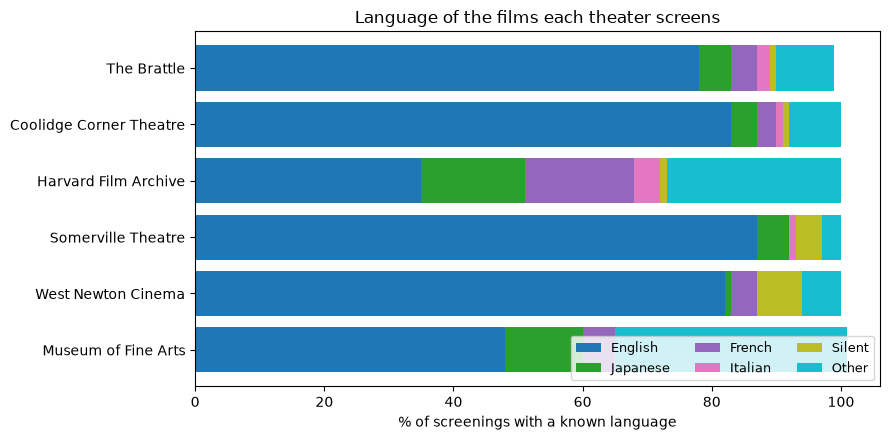

In [31]:
# your code here
busiest = df['theater'].value_counts().head(6).index
known = df.dropna(subset=['language'])
top = known['language'].value_counts().head(5).index
lang = known['language'].where(known['language'].isin(top), 'Other')
share = (pd.crosstab(known['theater'], lang, normalize='index').loc[busiest, [*top, 'Other']] * 100).round(0)
display.display(share)

ax = share.plot.barh(stacked=True, figsize=(9, 4.5), colormap='tab10', width=0.8)
ax.set(xlabel='% of screenings with a known language', ylabel='',
       title='Language of the films each theater screens')
ax.invert_yaxis()
ax.legend(loc='lower right', ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

**Question.** Where does Boston screen films in a language other than English, and in which languages? Q5 showed the Brattle and the Coolidge dominate the count; do they also dominate non-English programming?

**Approach.** For screenings with a known language, each of the six busiest theaters' share by language (top five plus Other) as a stacked bar, so theaters compare on composition rather than volume.

**Interpretation.** No. The Brattle and the Coolidge are 78% and 83% English; the Harvard Film Archive is 35% English with 17% French, 16% Japanese and 27% other, and the Museum of Fine Arts 48% English with 36% other. Non-English cinema lives in the two institutional venues, and Japanese and French are the second and third languages nearly everywhere.

In [32]:
# your code here
df.to_csv('data/movies_enriched.csv', index=False)
print(f"{os.path.getsize('data/movies_enriched.csv') / 1e6:.2f} MB, {df.shape[0]} rows x {df.shape[1]} columns")

0.35 MB, 2793 rows x 11 columns


In [33]:
grader.check("q8")

q8 results: All test cases passed!

### 8a. SQL — AC209A only (3 pts)

The DataFrame operations you've used all assignment — subset, aggregate, join, transform — are the same four verbs SQL speaks, and SQL is the dialect most of industry says them in (see the *DuckDB: SQL on files* supplemental). Pose one Q5-style analytical question about your enriched screening data and answer it with a **single SQL query** run via `duckdb` directly against `data/movies_enriched.csv`. Display the result and interpret it in 2–3 sentences. Prefer a question where SQL earns its keep (a grouped ranking, a window function, a multi-way aggregation).

In [34]:
# your code here
import duckdb
display.display(duckdb.sql("""
    SELECT theater, language, n,
           round(100.0 * n / sum(n) OVER (PARTITION BY theater), 1) AS pct_of_non_english
    FROM (SELECT theater, language, count(*) AS n
          FROM 'data/movies_enriched.csv'
          WHERE language IS NOT NULL AND language <> 'English'
            AND theater IN (SELECT theater FROM 'data/movies_enriched.csv'
                            GROUP BY theater ORDER BY count(*) DESC LIMIT 6)
          GROUP BY theater, language)
    QUALIFY row_number() OVER (PARTITION BY theater ORDER BY n DESC) <= 3
    ORDER BY theater, n DESC
""").df())

,theater,language,n,pct_of_non_english
0,Coolidge Corner Theatre,Japanese,32,25.4
1,Coolidge Corner Theatre,French,20,15.9
2,Coolidge Corner Theatre,German,13,10.3
3,Harvard Film Archive,French,49,25.8
4,Harvard Film Archive,Japanese,46,24.2
5,Harvard Film Archive,Korean,28,14.7
6,Museum of Fine Arts,Korean,7,31.8
7,Museum of Fine Arts,Japanese,5,22.7
8,Museum of Fine Arts,Persian,2,9.1
9,Somerville Theatre,Japanese,13,37.1


The query ranks each theater's non-English languages with `row_number()` over a partition and turns counts into shares with `sum() OVER`, which in pandas is a groupby, a sort, a cumcount and a merge. The HFA and the Brattle screen the same two languages at similar shares (French 26% and Japanese 24%; Japanese 22% and French 20%), the Coolidge leans Japanese (25%), and the Somerville's non-English programming is mostly Japanese and silent films (37% and 31%), a repertory-classics slant rather than world cinema.

## Question 9: The decision — program Halloween weekend

<p>You now advise a consortium of the <b>four theaters with the most screenings</b> in your data. They want a coordinated plan for <b>Halloween weekend 2026 (Fri Oct 30 – Sun Nov 1)</b>: each theater programs a small slate, with the goal of maximizing <b>total ticket revenue across the consortium</b> — so the theaters should draw large audiences <i>without competing head-to-head for the same one</i>.</p>

Produce a recommendation, supported by your data. There is no single right answer; you are graded on the clarity of your reasoning and on whether the data you present actually supports the recommendation you make.

### 9.1 Theater personalities

**Identify the four theaters** and characterize their programming "personalities" (the audience each one's history suggests it draws): genre mix, film vintage, language profile — whatever you judge informative. **Profile at least two theaters in depth** (all four encouraged), with at least one supporting visualization.

,screenings,median year,% non-English,% horror,% repeat bookings
theater,,,,,
The Brattle,1052,1987.0,22.0,12.0,31.0
Coolidge Corner Theatre,781,1992.0,17.0,15.0,14.0
Harvard Film Archive,404,1969.0,65.0,0.0,23.0
Somerville Theatre,281,1984.0,13.0,15.0,14.0


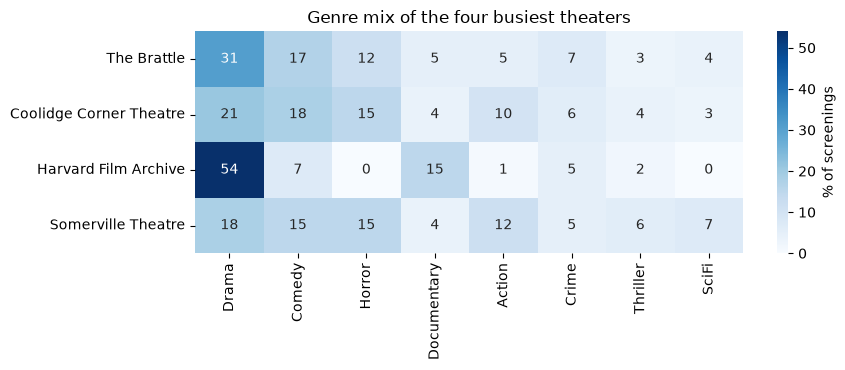

In [35]:
# your code here
top4 = df['theater'].value_counts().head(4).index
four = df[df['theater'].isin(top4)]
by = four.groupby('theater', observed=True)
profile = pd.DataFrame({
    'screenings': by.size(),
    'median year': by['year'].median(),
    '% non-English': by['language'].apply(lambda s: (s.dropna() != 'English').mean() * 100).round(0),
    '% horror': by['genre'].apply(lambda s: (s == 'Horror').mean() * 100).round(0),
    '% repeat bookings': by.apply(lambda g: g.duplicated('title').mean() * 100).round(0),
}).loc[top4]
display.display(profile)

genre_share = pd.crosstab(four['theater'], four['genre'], normalize='index').loc[top4] * 100
genre_share = genre_share[genre_share.sum().nlargest(8).index]
fig, ax = plt.subplots(figsize=(9, 3.8))
sns.heatmap(genre_share.round(0), annot=True, fmt='.0f', cmap='Blues', ax=ax, cbar_kws={'label': '% of screenings'})
ax.set(xlabel='', ylabel='', title='Genre mix of the four busiest theaters')
plt.tight_layout()
plt.show()

The Brattle is the repertory house: 1,052 screenings, median year 1987, drama 31% and comedy 17% with horror at 12%, and the highest re-booking rate, 31% of screenings being a title it had already run, so it keeps returning to a canon. The Coolidge is broadest and newest: 781 screenings, median 1992, drama 21%, comedy 18%, horror 15%, action 10%, and only 14% repeat bookings, a first-run-plus-events house. The Harvard Film Archive is the outlier: median 1969, 65% non-English, 54% drama, 15% documentary, no horror. The Somerville is the most mainstream: horror 15%, action 12%, sci-fi 7%, median 1984, 13% non-English, 14% repeats.

### 9.2 Your draw proxy

You have no revenue data, so state explicitly what you will use as a stand-in for "how many people a film/genre draws at this theater" and defend it in a sentence or two.

In [36]:
# your code here
d = four['screen_date']
window = four[((d.dt.month == 10) & (d.dt.day >= 24)) | ((d.dt.month == 11) & (d.dt.day <= 1))]
print('screenings in the Oct 24 - Nov 1 window, by year:', window['screen_date'].dt.year.value_counts().sort_index().to_dict())
print(window.groupby('theater', observed=True)['genre'].apply(lambda s: (s == 'Horror').mean() * 100).round(0).rename('% horror in the window'))
for t in top4:
    print(f"{t}: {', '.join(sorted(set(window.loc[window['theater'] == t, 'title']))[:10])}")

rebooked = (four[four['genre'].isin(['Horror', 'Thriller'])]
            .groupby(['theater', 'title', 'year', 'genre'], observed=True)['screen_date'].nunique()
            .rename('dates').reset_index().query('dates >= 2')
            .sort_values(['theater', 'dates'], ascending=[True, False]))
print('\nre-booked horror/thriller titles per theater:', rebooked.groupby('theater', observed=True).size().to_dict())
display.display(rebooked.groupby('theater', observed=True).head(4).reset_index(drop=True))

screenings in the Oct 24 - Nov 1 window, by year: {2024: 42, 2025: 42}
theater
Coolidge Corner Theatre    46.0
Harvard Film Archive        0.0
Somerville Theatre         43.0
The Brattle                41.0
Name: % horror in the window, dtype: float64
The Brattle: A Nightmare on Elm Street 3: Dream Warriors, Bram Stoker's Dracula, Death Race 2000, Eephus, Evil Dead II, Gods and Monsters, Jonathan, Kwaidan, Lady Dracula, Mandy
Coolidge Corner Theatre: 23rd Halloween Horror Marathon, 24th Halloween Horror Marathon, A Girl Walks Home Alone at Night, A Nightmare on Elm Street, Candyman, E.T. the Extra-Terrestrial, Ed Wood, Elbow, Elvira: Mistress of the Dark, Eraserhead
Harvard Film Archive: A Terra! The Cinema of Marta Mateus Program III, Army of Shadows, Brandos Costumes, Brother and Sister, Farpões, baldios / O Pão, Fire of Wind, Ginza Cosmetics, Harry Smith - Film No. 12 / Film No. 16, I Accuse!, Le Doulos
Somerville Theatre: Basket Case, Beetlejuice, Copycat, Friday the 13th, Ghostbus

,theater,title,year,genre,dates
0,Coolidge Corner Theatre,Eraserhead,1978,Horror,8
1,Coolidge Corner Theatre,Jaws,1975,Horror,5
2,Coolidge Corner Theatre,The Texas Chain Saw Massacre,1974,Horror,4
3,Coolidge Corner Theatre,Pulp Fiction,1994,Thriller,3
4,Harvard Film Archive,The Third Man,1949,Thriller,4
5,Harvard Film Archive,Killer's Kiss,1955,Thriller,2
6,Harvard Film Archive,"Suddenly, Last Summer",1959,Thriller,2
7,Somerville Theatre,Nosferatu,1922,Horror,2
8,Somerville Theatre,The Fog,1980,Horror,2
9,The Brattle,Jaws,1975,Horror,9


Two stand-ins. For a genre: the share of a theater's own Oct 24 – Nov 1 screenings in 2024 and 2025 (42 each year) that were horror, the theater's own bet on its Halloween week. For a film: the number of distinct dates a horror or thriller title has been booked at that theater over the two years, since a theater re-books what filled the room. Both are the theater's decisions, not attendance: a title can be re-booked because a print was available.

### 9.3 The slates

Recommend **2–3 films (or film types)** for each theater you profiled, and at least a one-line programming direction for the others. Justify choices with your profiles and draw proxy, and explain how the slates avoid cannibalizing each other.

**The Brattle**: the canon it re-runs, *Jaws* (9 dates) and *The Shining* (6), plus *Kwaidan* (5, in its window last year), a Japanese ghost anthology for its 22% non-English audience; *Nadja* (5) as alternate.

**Coolidge Corner**: the Halloween Horror Marathon it ran both years (23rd, 24th) as anchor, *Eraserhead* (8 dates, its most re-booked) as the late show, *The Texas Chain Saw Massacre* (4). Cult and midnight, not the Brattle's crowd.

**Harvard Film Archive**: no horror (it ran none in the window). Its thriller strand instead: *The Third Man* (4), *Killer's Kiss*, *Suddenly, Last Summer*, continuing the French line it ran (*Army of Shadows*, *Le Doulos*).

**Somerville**: the 1980s crowd-pleasers its window shows, *Beetlejuice*, *Ghostbusters*, *Little Shop of Horrors*, with *Nosferatu* (re-booked twice) as the Sunday silent.

Four audiences, no overlap: canon horror, cult and marathon, noir and international, family and comedy-horror.

### 9.4 Uncertainties

At least two ways this analysis could mislead the consortium, and what data you'd want next.

Screenings are not tickets: a re-booking can mean a print was available, so I would want per-screening attendance or box office. The history is Wayback snapshots with gaps (Q4's days-covered column), so each Halloween window is only 42 screenings; the theaters' own calendars would fix that. Language is known for 88% of screenings, and neither it nor the genre labels cover the programme listings and marathons that matter most at Halloween.

## Question 10: Reproducibility reflection, AI disclosure & data submission

### 10.1 Reproducibility reflection

A short paragraph or bullets: walk through your pipeline and identify what is **reproducible** (same result on every re-run, for anyone) and what is **brittle or non-reproducible** — and how you mitigated each risk. Consider at least: the live fetch (Q1), your HTML parsing (Q2), the Wayback snapshots (Q3), and the Wikipedia lookups & content (Q6–Q8). Also: the raw wiki cache is *deliberately excluded* from your submission (see 10.3) — what does that exclusion mean for the reproducibility of your Q8 columns?

Reproducible: the Wayback snapshots (Q3), pinned by timestamp and cached per file, from which movies.json is rebuilt; the Wikipedia IDs (Q6), read from wiki_ids.csv and produced by a deterministic resolver (category check, sorted tiebreak); the Q8 columns, read from the submitted wiki_languages.csv. Brittle: the live page (Q1) is one day's snapshot, so it is fetched once and never again; the parser (Q2) is tied to one layout and did break on the old design, so it reports parsed and failed counts per file; the lookups assume Wikipedia keeps its articles, so the numeric pageid is cached rather than the title. Excluding data/wiki/ means the Q8 columns re-run identically from the CSV but cannot be re-derived offline, and since infoboxes drift as articles are edited, a refetch may not reproduce them exactly.

### 10.2 AI disclosure

A few sentences: how you used AI tools on this assignment (which parts, what for) and — the part we grade — **what you did to verify their output** before signing off on it. There is no penalty for extensive AI use; there is a penalty for unverified submission.

During the preparation of this work, we used coding assistants (Claude, ChatGPT, Cursor) to assist with drafting and editing text and code. We reviewed and edited all content and take full responsibility for it: every check was re-run cold and warm, every number in the written answers was checked against the printed output, and the notebook was run offline as it will be graded.

### 10.3 Data submission

Run the provided manifest cell below. You will upload these files with your notebook so it can be re-run and graded *without any network access*. The full set must stay **under 25 MB** — this is why Q7 cached page content to disk instead of stuffing it in the DataFrame.

In [37]:
# --- PROVIDED CELL: submission manifest. Run before submitting; do not edit.
# Your submission = this notebook + every file listed below (data/wiki/ raw
# page cache is deliberately excluded). The set must total <= 25 MB.
SUBMISSION_FILES = sorted(
    glob.glob("data/html/*.html")     # live page + pinned snapshots
    + glob.glob("data/*.json")        # movies.json, wayback manifest, ...
    + glob.glob("data/*.csv")         # your derived caches / enriched table
)

assert SUBMISSION_FILES, "No data files found -- did the pipeline run?"
assert any("movies_enriched" in f for f in SUBMISSION_FILES), \
    "data/movies_enriched.csv is required (Q8)."

total_mb = sum(os.path.getsize(f) for f in SUBMISSION_FILES) / 1e6
for f in SUBMISSION_FILES:
    print(f"{os.path.getsize(f)/1e6:8.2f} MB  {f}")
print(f"{'-'*40}\n{total_mb:8.2f} MB  total ({len(SUBMISSION_FILES)} files)")

assert total_mb <= 25, "Submission exceeds the 25 MB budget!"
print("\nWithin the 25 MB budget -- ready to submit.")

    0.30 MB  data/html/screenboston.html
    0.01 MB  data/html/snapshot_20240328.html
    0.26 MB  data/html/snapshot_20240524.html
    0.16 MB  data/html/snapshot_20240621.html
    0.23 MB  data/html/snapshot_20240727.html
    0.24 MB  data/html/snapshot_20240803.html
    0.20 MB  data/html/snapshot_20240812.html
    0.25 MB  data/html/snapshot_20240904.html
    0.20 MB  data/html/snapshot_20240912.html
    0.26 MB  data/html/snapshot_20240921.html
    0.26 MB  data/html/snapshot_20240924.html
    0.37 MB  data/html/snapshot_20240926.html
    0.31 MB  data/html/snapshot_20241006.html
    0.22 MB  data/html/snapshot_20241101.html
    0.18 MB  data/html/snapshot_20241108.html
    0.17 MB  data/html/snapshot_20241119.html
    0.16 MB  data/html/snapshot_20241206.html
    0.14 MB  data/html/snapshot_20241210.html
    0.14 MB  data/html/snapshot_20241211.html
    0.14 MB  data/html/snapshot_20241212.html
    0.14 MB  data/html/snapshot_20241214.html
    0.17 MB  data/html/snapshot_2024121

In [38]:
grader.check("q10_3")

q10_3 results: All test cases passed!

## Wrap-up

<div class="alert alert-info" style="color: #4a4a4a; background-color: #fbe8ff; border-color: #eed4db; border-width: 1px; border-radius: 3px; padding: 10px;">

* Which aspect(s) of the assignment did you find most challenging — conceptually or in implementation? Any remaining questions?

* How many hours did you spend on this assignment? Store an int or float in `hours_spent_on_hw` (if you worked in a group, report the average per person).

</div>

The hardest part was Q6: a Wikipedia lookup that is cheap in requests and actually correct, since a live page is not evidence (redirects land on the wrong film, disambiguation pages look like hits) and search returns same-year films with the wrong title. Open question: how the offline re-run treats a notebook whose raw wiki cache is excluded by design.

In [39]:
hours_spent_on_hw = 8

In [40]:
grader.check("wrapup")

wrapup results: All test cases passed!

In [41]:
notebook_end = time.time()
print(f"It took {(notebook_end - notebook_start)/60:.2f} minutes for this notebook to run")

It took 0.03 minutes for this notebook to run


🌈 **This concludes HW1. Thank you!**